<b>Checking that we are on the correct path and we are also using the correct venv and kernel</b>

In [1]:
import sys
sys.executable

'/Users/grigoriostsakalis/Desktop/Titanic - ML Project/titanic_venv/bin/python'

<b>First step was to setup the whole environment that I will be working on for this project. Eventually, VS Code was used in combination with a jupyter notebook file but WITHOUT the usage of Anaconda</b>

<b>Second step is to read and understand the problem, perhaps write a few insights about it underneath</b>

<b>Third step will be setting up the data, and applying Exploratory Data Analysis and Data Preprocessing</b>

<b>Last step in this "chapter" will be to make, train, and test an ml model to see how it performs.</b>

<b><i>Once all these are tackled, then I will try and improve the performance by applying different EDA and Data Preprocessing methods, along with choosing different ML models perhaps</i></b>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Imported the libraries needed for the third step which is applying EDA and Data Preprocessing. 
Later I will also import the extra scikit-learn in order to start working with ML models and get
more tools and choices to work with.

In [3]:
train_data = pd.read_csv("../data/train.csv")
test_data = pd.read_csv("../data/test.csv")

In [4]:
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
test_data.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


----------------------------------------
----------------------------------------
---------------------------------------
## EDA (Exploratory Data Analysis)

Later, after finishing EDA and Data Preprocessing, use the code below to import the basic tools
and functions required for the first ML model that I will be using.

Machine Learning <br>
from sklearn.model_selection import train_test_split <br>
from sklearn.linear_model import LogisticRegression <br>
from sklearn.metrics import accuracy_score <br>

<b>EDA will now take place using a couple of different categories to use like:<br>

- Dataset Overview: understand scale and structure by looking at number of columns / rows, and categorical vs numerical split 

- Missing data analysis: understand pattern by looking at percentage of missing values, which columns have mising values and are these missing values random or systematic?

- Univariate analysis: understand each variable in isolation by looking at mean, median, standard deviation, min / max, STD and Variance

- Correlation analysis: detect linear relationships by looking at correlation matrices nad pairwise correlations

- Outlier inspection: understand whether outliers exist and if they are rare/frequent and plausible or not, and using z-score intuition (not actually normalising just yet)

----------------------------------------
----------------------------------------
### Dataset Overview

In [6]:
train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


*By looking at the above info, we can see that the <u>Cabin</u> column has the most null values, while the <u>Ticket</u> and <u>PassengerId</u> columns don't necessarily give any major feedback that will be useful for predicitons, which makes them weak candidates for the model and they will be most definitely removed.

Apart from that, for the rest of the dataset's columns: <br>
The categorical columns of the dataset are "Survived", "Pclass(?)", "Sex", "Embarked" <br>
The numerical colunmns are "Age", "Sibsp", "Parch", "Ticket", "Fare".
<br><br>
These columns will be kept, the others will be deleted, and also the "Sex" column will be changed from male and female to 1 and 0.

In [7]:
train_data.drop(labels=["Cabin", "Ticket"],axis=1, inplace=True)
test_data.drop(labels=["Cabin", "Ticket"],axis=1, inplace=True)
# "PassengerId"
# "PassengerId"

In [8]:
for dataset in [train_data, test_data]:
    dataset.loc[dataset['Sex'] == 'male', 'Sex'] = "1"
    dataset.loc[dataset['Sex'] == 'female', 'Sex'] = "0"
    dataset["Sex"] = dataset["Sex"].astype(int)

In [9]:
train_data.head()
test_data.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
0,892,3,"Kelly, Mr. James",1,34.5,0,0,7.8292,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",0,47.0,1,0,7.0000,S
2,894,2,"Myles, Mr. Thomas Francis",1,62.0,0,0,9.6875,Q
3,895,3,"Wirz, Mr. Albert",1,27.0,0,0,8.6625,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",0,22.0,1,1,12.2875,S


----------------------------------------
----------------------------------------
### Missing data analysis

In [10]:
train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    int64  
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Fare         891 non-null    float64
 9   Embarked     889 non-null    str    
dtypes: float64(2), int64(6), str(2)
memory usage: 69.7 KB


In [11]:
test_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    str    
 3   Sex          418 non-null    int64  
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Fare         417 non-null    float64
 8   Embarked     418 non-null    str    
dtypes: float64(2), int64(5), str(2)
memory usage: 29.5 KB


*By looking at the data on both datasets, it is visible that the "Age" column provides two issues: <br>
1) It has null values 
2) It is of type float, and of course an age can never be of float value
<br><br>

So first of all, I will look into the float matter and check if there is any record where there are decimal values apart rather than ".0". If not, then that means that we can just "switch" the data type into int pretty straightforward.

In [12]:
train_data.loc[(train_data["Age"] % 1 != 0) & (train_data["Age"].notna())]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
57,58,0,3,"Novel, Mr. Mansouer",1,28.50,0,0,7.2292,C
78,79,1,2,"Caldwell, Master. Alden Gates",1,0.83,0,2,29.0000,S
111,112,0,3,"Zabour, Miss. Hileni",0,14.50,1,0,14.4542,C
116,117,0,3,"Connors, Mr. Patrick",1,70.50,0,0,7.7500,Q
122,123,0,2,"Nasser, Mr. Nicholas",1,32.50,1,0,30.0708,C
123,124,1,2,"Webber, Miss. Susan",0,32.50,0,0,13.0000,S
148,149,0,2,"Navratil, Mr. Michel (""Louis M Hoffman"")",1,36.50,0,2,26.0000,S
152,153,0,3,"Meo, Mr. Alfonzo",1,55.50,0,0,8.0500,S
153,154,0,3,"van Billiard, Mr. Austin Blyler",1,40.50,0,2,14.5000,S
203,204,0,3,"Youseff, Mr. Gerious",1,45.50,0,0,7.2250,C


In [13]:
test_data.loc[(test_data["Age"] % 1 != 0) & (test_data["Age"].notna())]

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
0,892,3,"Kelly, Mr. James",1,34.50,0,0,7.8292,Q
27,919,3,"Daher, Mr. Shedid",1,22.50,0,0,7.2250,C
35,927,3,"Katavelas, Mr. Vassilios (Catavelas Vassilios"")""",1,18.50,0,0,7.2292,C
73,965,1,"Ovies y Rodriguez, Mr. Servando",1,28.50,0,0,27.7208,C
75,967,1,"Keeping, Mr. Edwin",1,32.50,0,0,211.5000,C
109,1001,2,"Swane, Mr. George",1,18.50,0,0,13.0000,S
113,1005,3,"Buckley, Miss. Katherine",0,18.50,0,0,7.2833,Q
136,1028,3,"Zakarian, Mr. Mapriededer",1,26.50,0,0,7.2250,C
152,1044,3,"Storey, Mr. Thomas",1,60.50,0,0,NaN,S
192,1084,3,"van Billiard, Master. Walter John",1,11.50,1,1,14.5000,S


*Turns out there are a couple of records that have strange numbers in the decimal area including normal ages with the .50 decimal value and also value less than 1 like 0.75, 0.83, and so on! <br><br>
For the normal ages with the <u>0.50</u> values, I can think of only two possible reason why these exist:
1) The ages show that some people were at or after the half of their "extra year" so that a 41.5 would mean that the person is almost 42. Age estimation rounding from source data.
2) There was some sort of database conversion that didn't work out

<br>

For the <u>less than 1</u> ages I have three possible reasons why these exist, with one of them not really being plausible since the NaN values debunk it:
1) There was data entry error and instead of 75.0, someone may have input 0.75
2) Age got corrupted during data conversion/import
3) They were used as placeholder valued temporarily in order to be filled later (unlikely since I wouldn't have 202 NaN values if that was the case)

------------------------------
<b>Now about the missing data analysis on the rest of the columns,</b> when looking at the .info() results, it is visible on both of the datasets that there are not missing/NaN values and the data types for each one seem reasonable as well (Sex->int 0 or 1, SipSp->int, Parch->int, etc).

<b>BUT</b> the Fare column seems to have one missing/NaN value on the test dataset which will have to be checked later on, and since its a float value it would be wise to check out some of its values:

In [14]:
train_data["Fare"]

0       7.2500
1      71.2833
2       7.9250
3      53.1000
4       8.0500
        ...   
886    13.0000
887    30.0000
888    23.4500
889    30.0000
890     7.7500
Name: Fare, Length: 891, dtype: float64

In [15]:
# Check for any non-4 decimal values
non_four_decimals = train_data[train_data["Fare"].astype(str).str.split('.').str[1].str.len() != 4]
print(f"Values without 4 decimals: {len(non_four_decimals)}")
print(non_four_decimals["Fare"].head(10))

Values without 4 decimals: 600
0      7.250
2      7.925
3     53.100
4      8.050
7     21.075
10    16.700
11    26.550
12     8.050
13    31.275
15    16.000
Name: Fare, dtype: float64


*By looking at the couple of values that are coming up, it is visible that those are not normal prices for a ticket to a cruise ship. 4 decimal values that cannot even be interpreted with real money can mean plenty of things:
1) Data may have been corrupted if it went through multiple systems or formats, however all of the fares have exactly 4 decimals so its not sporadic- rather quite systematic, meaning intentional work
2) There may have been some sort of currency conversion but its unlikely because historically currency conversion result in cleaner numbers or at least consistent rounding.
3) Decimal point shift may have occured e.g. 71.2833 -> 7128.33 but this is quite sporadic since NOT ALL of the records have 4 decimals, some have three. So even if this theory is interesting, it is not fully reliable.
<br><br>
At last, what may have happened is a classic precision/rounding from the original source data, where passenger fares from 1912 might have been recorded as shillings, converted with extra precision, or aggregated/approximated statistically

*When <b>data preprocessing</b> is applied, I will either <u>round everything into 2 decimal places </u>OR I will <u>keep as-are</u> if the model ends up performing well!

----------------------------------------
----------------------------------------
### Univariate analysis

**understand each variable in isolation by looking at mean, median, standard deviation, min / max**

Let's start with the <u>Pclass column</u>.

In [16]:
print(test_data["Pclass"].mean())
print(test_data["Pclass"].median())
print(test_data["Pclass"].std())
print(test_data["Pclass"].min())
print(test_data["Pclass"].max())

print("------------\nFor train data:")
print(test_data["Pclass"].mean())
print(test_data["Pclass"].median())
print(test_data["Pclass"].std())
print(test_data["Pclass"].min())
print(test_data["Pclass"].max())

2.2655502392344498
3.0
0.8418375519640503
1
3
------------
For train data:
2.2655502392344498
3.0
0.8418375519640503
1
3


By looking at these metrics, a few things can be discussed:
- A mean of <b>≈ 2.3</b> doesn't tell anything by itself, but when compared with the median value of <b>3</b> it shows that the data is skewed towards the 3rd class. This is because between the small range 1-3, the 2.3 to 3 difference is actually a significant gap, and since the median returned 3 then that tells that the data is heavily weighted towards the 3rd class. 
<br><br>
- An STD of ≈ 0.85 on a column with a range of 1-3 shows since that the variance is quite high which means that the values are spread out across the range, WITHOUT implying that they're evenly distriputed/spread out. The median of 3 helps understand what the data is overall spread out and are NOT clustered mostly on one class, and that they're more spicifically skewed towards the 3rd class.

There might be a few reasons why there are more people on board at the 3rd class, some of them are:
1) The ship was designed to carry more lower-3rd-class passengers
2) 3rd class tickets were cheaper/more accessible
3) It reflects the era's stratification/there were mor 3rd class people around
4) The ship had capacity constraints however they were packing in cheaper passengers to maximise profit (resulted in more people on board than the lifeboats could support)

----------------------------------------
For the <u>Name column</u>

*There is no easy way of appplying Univariate analysis on categorical-text data. Finding some sort of median, mean, std, min, max- won't lead me to any conclusions. On top of that, each name is unique and the only reason a column like this would be useful would be by finding how many people with the same surname are on board which would imply that since they're a family there would be different chances of surviving than people travelling solo. However, this point is tackled through the usage of SipSp and Parch columns which capture family relationships better than surnmame matching. <br><br>
Therefore, according to the above and for this "first walkthrough" of the dataset I will be removing the <u>Name</u> column from the dataset.

In [17]:
for dataset in [train_data, test_data]:
    dataset = dataset.drop("Name", axis=1, inplace=True)
print(train_data.head(5))
print(test_data.head(5))

   PassengerId  Survived  Pclass  Sex   Age  SibSp  Parch     Fare Embarked
0            1         0       3    1  22.0      1      0   7.2500        S
1            2         1       1    0  38.0      1      0  71.2833        C
2            3         1       3    0  26.0      0      0   7.9250        S
3            4         1       1    0  35.0      1      0  53.1000        S
4            5         0       3    1  35.0      0      0   8.0500        S
   PassengerId  Pclass  Sex   Age  SibSp  Parch     Fare Embarked
0          892       3    1  34.5      0      0   7.8292        Q
1          893       3    0  47.0      1      0   7.0000        S
2          894       2    1  62.0      0      0   9.6875        Q
3          895       3    1  27.0      0      0   8.6625        S
4          896       3    0  22.0      1      1  12.2875        S


----------------------------------------
For the <u>Sex column</u> which has been changed from categorical-text type into categorical-numerical type inlcuding 0s for Females and 1s for Males

In [18]:
print(test_data["Sex"].mean())
print(test_data["Sex"].median())
print(test_data["Sex"].std())
print(test_data["Sex"].min())
print(test_data["Sex"].max())

print("------------\nFor train data:")
print(test_data["Sex"].mean())
print(test_data["Sex"].median())
print(test_data["Sex"].std())
print(test_data["Sex"].min())
print(test_data["Sex"].max())

0.6363636363636364
1.0
0.4816221409322309
0
1
------------
For train data:
0.6363636363636364
1.0
0.4816221409322309
0
1


*By looking at these values we make some assumptions:
- A <b>mean</b> of <b>0.63</b> compared to a median of <b>1</b> shows that the data is skewed more to the max value which is 1, meaning that <u>most records within the datasets are male</u>.
<br><br>
- For an STD with range 0-1, a value of <u>0.5 would mean a perfectly balanced split (50/50)</u>, while <u>0 would mean heavily skewed towards one side male or female</u> (w/out implying which of the two). Also, the <u>std CANNOT be more than 0.5 for a binary column</u> mathematically. At last, the <b>std</b> I get of <b>0.48</b> is really close to 0.5, which implies that <u>the data is almost perfectly balanced</u> while some "skewesness" still exists within and it is most defintely male centered because of the median being 1.

----------------------------------------
For the <u>Age column</u>, which has aroused a couple of issues and thoughts around it since it is of type float and includes values like 70.5 or 0.67 as ages for some records- something definitely not realistic- it will be taken care of on the data preprocessing stage.

In [19]:
print(test_data["Age"].mean())
print(test_data["Age"].median())
print(test_data["Age"].std())
print(test_data["Age"].min())
print(test_data["Age"].max())

print("------------\nFor train data:")
print(test_data["Age"].mean())
print(test_data["Age"].median())
print(test_data["Age"].std())
print(test_data["Age"].min())
print(test_data["Age"].max())

30.272590361445783
27.0
14.181209235624422
0.17
76.0
------------
For train data:
30.272590361445783
27.0
14.181209235624422
0.17
76.0


*By looking at these metrics we can make a couple of assumptions:
- The mean value of 30.27 is reasonably close with the median value of 27, since the range of the column is 0.17 to 76. This means that the data is fairly summetric, not heavily skewed. Median 27 means that half of the passengers are younger than 27 and half are older (with the current data format, without it being preprocessed).

- The 14.18 value for STD also provides crucial info and shows that based on the rule of thumb for finding a rough max std (max -min)/4, which returns max_std=19 for this column, we understand that an STD of 14.18 is not too high and neither too low. It's below the theoretical max, so it means that the data are moderately spread. Moderately spread means that the passengers varied in age but not extremely.

<br>
All in all, the insights from this column circle back to the fact that the Titanic primarly carried young to middle-aged adults (centered around 27-30 yeals old), rather than elder and younger passengers which existed but didn't dominate. However, diversity exists between the ages and overall the column can be a good candidate to provide predictive values.


----------------------------------------
For the <u>SibSp column</u>, which refers to the numbers of relatives each person (record) had aboard. The relatives that fall under this category are siblings (brother, sister, stepbrother, stepsister), and spouse (husband, wife, not mistresses and fiancés).

In [20]:
print(test_data["SibSp"].mean())
print(test_data["SibSp"].median())
print(test_data["SibSp"].std())
print(test_data["SibSp"].min())
print(test_data["SibSp"].max())

print("------------\nFor train data:")
print(test_data["SibSp"].mean())
print(test_data["SibSp"].median())
print(test_data["SibSp"].std())
print(test_data["SibSp"].min())
print(test_data["SibSp"].max())

0.4473684210526316
0.0
0.8967595611217135
0
8
------------
For train data:
0.4473684210526316
0.0
0.8967595611217135
0
8


*Looking at these metrics, again we get some valuable information:
- The mean value of 0.44 compared to the median value of 0, while max is 8 and min is 0- this COULD potnetially mean that the data is fairly symmetric and not heavily skewed. HOWEVER, since the median is 0 and that means most people cluster at 0, then the gap between these mean and median values is actually significant. Also, the presence of passengers with up to 8 relatives creates a right-skewed distribution where some people pull the mean higher than the median ==> mean(0.44) > median(0).
Eventually, the above result in the assumption that most people on board didn't have any sort of relatives of the above type on board or they were travelling alone.

- Also, the median of 0 in combination with the STD of 0.89 shows that most people had 0 relatives, but there is decent variation when people that DO have relatives! Since most of them are on the median value of 0, and since the STD gets the variance from the median, then these mean that family that DID have relatives, were decently ditributed from that median.

<br>
In conclusion, most people on the Titanic had 0 relatives (of the ones this column refers to), however there are enough passengers with 1-8 relatives that are decently distributed. This column can be predictive since it imposes the prediction of survival between solo vs family travelers.

----------------------------------------
For the <u>Parch column</u>, which refers to the numbers of relatives each person (record) had aboard. The relatives that fall under this category are parents (mother, father) and children (daughter, son, stepdaughter, stepson).

In [21]:
print(test_data["Parch"].mean())
print(test_data["Parch"].median())
print(test_data["Parch"].std())
print(test_data["Parch"].min())
print(test_data["Parch"].max())

print("------------\nFor train data:")
print(test_data["Parch"].mean())
print(test_data["Parch"].median())
print(test_data["Parch"].std())
print(test_data["Parch"].min())
print(test_data["Parch"].max())

0.3923444976076555
0.0
0.9814288785371691
0
9
------------
For train data:
0.3923444976076555
0.0
0.9814288785371691
0
9


*Now onto the Parch colunmn the assumptions we can make are similar to the ones on the SibSp column:
- Mean value is 0.39 and median value is 0.0. The gap is significant since the range is not big (0->9). This comparsion shows that most people travelling on board were travelling solo, or most definitely and based on this column alone, most people were travelling without parents or children.

- On the std value, the rough max std value is 2.25. So roughly, max STD (major distribution) would be 2.25- medium distribution would be 1.125, and low distribution (most passengers clustered to one group) would be closer to 0. The value of STD 0.98 showcases that the passengers that did NOT travel alone (because whoever did travel alone is clustered within the median and std is about the variance from the median) are pretty evenly distributed among the 1->9 range.

<br>
Overall, the main conclusion from this column is that most people that were travelling were by themselves (without any parents or children more specifically) and the rest of the passengers were enough to bring up the mean value while also were evenly distributed along the 1->9 range. This column is quite predictively important since it can be strictly connected with the survival percentage of a person.

<b> Coefficient of Variation (CV) = (Std / Mean) × 100 </b>

-- Before moving on, let's quickly check the CV of the SibSp and Parch columns. The Coefficient of Variation (CV) is used when comparing how "varied" two columns may be. TO do that we need to look at relative variation which is the percentage of variability relative to the mean. Using the formula above, I get these two values:
 
* SibSp = 202% CV
* Parch = 251% CV

This comparison shows that Parch is actually MORE varied than the SibSp column. So, <u>more variation</u> means more "different values" (rather than just 1-2 number of siblings, the children and parents on board were 1-8 more). This more variation means that <u>the column captures more nuanced differences</u>, which immediately means <u>more predictively important</u> since it <b>distinguishes between different types of family structures</b>

----------------------------------------
For the <u>Fare column</u>, which contains like we've said before some questionable values. Some very low, some quite high, some with up to 4 decimals and others with 3 or less. However, it is worth applying univariate analysis to it as well in case we can make some sort of assumptions about it before we move on to the next EDA topic which is <b>Correlation Analayis</b> (and later Outlier inspection)

In [22]:
print(test_data["Fare"].mean())
print(test_data["Fare"].median())
print(test_data["Fare"].std())
print(test_data["Fare"].min())
print(test_data["Fare"].max())

print("------------\nFor train data:")
print(test_data["Fare"].mean())
print(test_data["Fare"].median())
print(test_data["Fare"].std())
print(test_data["Fare"].min())
print(test_data["Fare"].max())

35.627188489208635
14.4542
55.907576179973844
0.0
512.3292
------------
For train data:
35.627188489208635
14.4542
55.907576179973844
0.0
512.3292


*So by looking at these also very questionable metrics we can say a few things about the actual column:
- Mean value of 35.62 and median of 14.45 shows that half of the people paid (supposedly) an approximate price of less than 14.4542 and other half paid more than that. In combination with the mean of 35.62, these two show that the data is right-skewed and that most people were closer to the lower end of the fare-range.

- Additionally, the STD of 55.90 where the rough max std is 128.08, shows medium distribution of the fares of the titanic. This means that most of the passengers paid relatively around the same lower fares- however because of a smaller group of people paying significant more this resulted in the data being right-skewed. Maybe this is connected with the fact that most people on board were on the 3rd class, therefore more people paid that lower-end (around the median) fare ticket rather than more.

In conclusion, the Fare column is a strong predictor since it is connected with the passenger class stratification that I mentioned on the Pclass univariate analysis. Most people paid little- indicating more people on the 3rd class on board, while wealthy passengers' high fares pulled the mean up dramatically.

----------------------------------------
For the <u>Embarked column</u>, which has categorical-text values of C, Q, and S- I will be temporarily adding a new column which replaces the values with 0,1,2 correspondigly. After that, I will apply the univariate analysis on the column and then I will drop the new column.

In [23]:

embarked_map = {"C": 0, "Q": 1, "S": 2}
train_data["Embarked_num"] = train_data["Embarked"].map(embarked_map)
test_data["Embarked_num"] = test_data["Embarked"].map(embarked_map)


print(test_data["Embarked_num"].mean())
print(test_data["Embarked_num"].median())
print(test_data["Embarked_num"].std())
print(test_data["Embarked_num"].min())
print(test_data["Embarked_num"].max())

print("------------\nFor train data:")
print(test_data["Embarked_num"].mean())
print(test_data["Embarked_num"].median())
print(test_data["Embarked_num"].std())
print(test_data["Embarked_num"].min())
print(test_data["Embarked_num"].max())

train_data.drop("Embarked_num", axis=1, inplace=True)
test_data.drop("Embarked_num",  axis=1, inplace=True)


1.4019138755980862
2.0
0.8544964564020431
0
2
------------
For train data:
1.4019138755980862
2.0
0.8544964564020431
0
2


*When looking at the metrics I make these assumptions:
- The mean is 1.40 and the median is 2, thats a very singifican gap when taking into account the range of 0-2. The median tells me that most passengers embarked from Southampton and the data of the column is left skewed meaning some people from Queenstown and Cherbourg pulled the average down (mean < median)

- On top of that, when adding to the equation the std of 0.85 (where the theoritical max std for the 0-2 range is 1.0), it shows that the distribution is high which means that the values are highly dispersed across the three ports and there are no visible groupings.

Eventually, the only extra metric I could use to get a good idea of the passengers' embarkated locations would be by using a bar plot

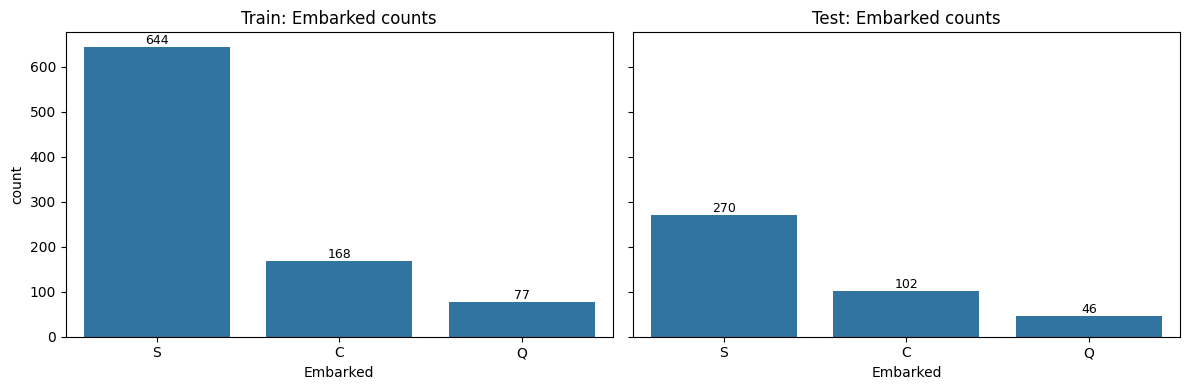

Train %:\n Embarked
S    72.44
C    18.90
Q     8.66
Name: proportion, dtype: float64
Test  %:\n Embarked
S    64.59
C    24.40
Q    11.00
Name: proportion, dtype: float64


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
order = ['S', 'C', 'Q']

sns.countplot(x='Embarked', data=train_data, order=order, ax=axes[0])
axes[0].set_title('Train: Embarked counts')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x()+p.get_width()/2, p.get_height()), ha='center', va='bottom', fontsize=9)

sns.countplot(x='Embarked', data=test_data, order=order, ax=axes[1])
axes[1].set_title('Test: Embarked counts')
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}', (p.get_x()+p.get_width()/2, p.get_height()), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print('Train %:\\n', train_data['Embarked'].value_counts(normalize=True).mul(100).round(2))
print('Test  %:\\n', test_data['Embarked'].value_counts(normalize=True).mul(100).round(2))


*As seen from the plots, the assumptions that were previously mentioned are mostly right. Most passengers did in fact embarked from southampton and generally distribution is concentrated at S rather than Cherbourgh (G) and Queenstown (Q) which had fewer passengers.

Additionally, one final assumption that can be made is that since most people on board paid a lower-end fare and had tickets for 3rd class- and since most passengers were from southampton- then these lead to the assumption that most passengers were medium to low end of wealth-type-people living in southampton. This combination of the three different Pclass, Fare, and Embarked columns leads to a promising predictive combination, and they will most definitely help the model learn better patterns.

----------------------------------------
----------------------------------------
### Correlation analysis

*detect linear relationships by looking at correlation matrices and pairwise correlations*

*First thing I will be doing is using a heatmap to visualise all pairwise correlations at once, in order to quickly spot which columns may be moving together most importantly focus on column correlations with the Survived column.

             PassengerId  Survived    Pclass       Sex       Age     SibSp  \
PassengerId     1.000000 -0.005007 -0.035144  0.042939  0.036847 -0.057527   
Survived       -0.005007  1.000000 -0.338481 -0.543351 -0.077221 -0.035322   
Pclass         -0.035144 -0.338481  1.000000  0.131900 -0.369226  0.083081   
Sex             0.042939 -0.543351  0.131900  1.000000  0.093254 -0.114631   
Age             0.036847 -0.077221 -0.369226  0.093254  1.000000 -0.308247   
SibSp          -0.057527 -0.035322  0.083081 -0.114631 -0.308247  1.000000   
Parch          -0.001652  0.081629  0.018443 -0.245489 -0.189119  0.414838   
Fare            0.012658  0.257307 -0.549500 -0.182333  0.096067  0.159651   

                Parch      Fare  
PassengerId -0.001652  0.012658  
Survived     0.081629  0.257307  
Pclass       0.018443 -0.549500  
Sex         -0.245489 -0.182333  
Age         -0.189119  0.096067  
SibSp        0.414838  0.159651  
Parch        1.000000  0.216225  
Fare         0.216225  1.

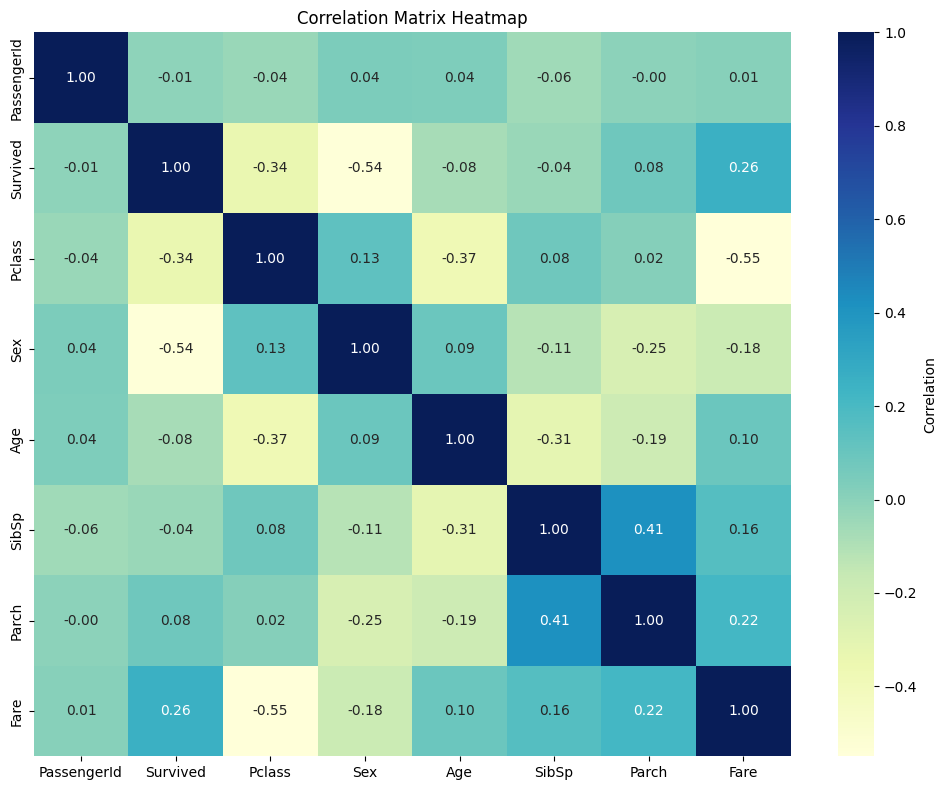

In [25]:
%matplotlib inline
# Compute correlation matrix
co_mtx = train_data.corr(numeric_only=True)

# Print correlation matrix
print(co_mtx)

# Create figure with explicit size
plt.figure(figsize=(10, 8))

# Plot correlation heatmap
sns.heatmap(co_mtx, cmap="YlGnBu", annot=True, fmt='.2f', cbar_kws={'label': 'Correlation'})
plt.title('Correlation Matrix Heatmap')
plt.tight_layout()

# Display heatmap
plt.show()

*By having a quick look at the heatmap, I can make a few basic assumptions:
- The strongest correlated column to the <u>Survived</u> column is the <u>Sex</u> column. This verifies the historically accurate fact that women and children were prioritised- therefore it's like very predictive and I will be keeping it for the model to use.

- Another assumption that I could make, outside of the Survived column, is the correlation between the <u>Pclass</u> and the <u>Fare</u> columns. These two have a strong correlation (based on the rest of the correlations ofc, not generally strong in the range 0-1), and this also validates the data quality. Since higher fare means usually high class, and vice versa, then that's verified through this correlation (keep in mind the correlation would probably be negative since the lower a fare is the highest the class is, since the "high class" of 3 refers to lower/cheapest quality class).

Additionally, it would be wise to apply Multicollinearity check, which looks at correlations between predictors (all the column except Survived), in order to see if data is still validated and also if the data- which is not preprocessed- influences the relationships at all.

<b>Multicollineariry</b> refers to the high correlation of two or more predictor columns with each other (and not with the target).

One example of this are the two <u>Fare</u> and <u>Pclass</u> columns which like said above, have a high correlation between them, but that doesn't mean that it's "good". The two columns measure almost the same thing (wealth) therefore the model might get confused and won't be able to tell which is important.

So, in order to check even further which of the columns showcase multicollinearity that it's not repeating data (redundancy), I will use the code below to print the min and the max correlation of each column (the min because the lowest a negative correlation is, the strongest it is, and vice versa for the max).

In [26]:
print("Top correlations with Survived (positive & negative):")
survived_corr = co_mtx['Survived'].sort_values(ascending=False)
print(survived_corr)

print("\n\nMulticollinearity check (predictors only):")
# Get absolute correlations for predictors (exclude Survived)
predictors = co_mtx.drop('Survived', axis=0).drop('Survived', axis=1)
# print(predictors)

print("\nHighest correlations among predictors:")
for col in predictors.columns:
    # Sort by absolute value to catch both negative & positive
    top_corrs = predictors[col].abs().sort_values(ascending=False)[1:3]
    print(f"{col}: {top_corrs.to_dict()}")

Top correlations with Survived (positive & negative):
Survived       1.000000
Fare           0.257307
Parch          0.081629
PassengerId   -0.005007
SibSp         -0.035322
Age           -0.077221
Pclass        -0.338481
Sex           -0.543351
Name: Survived, dtype: float64


Multicollinearity check (predictors only):

Highest correlations among predictors:
PassengerId: {'SibSp': 0.05752683378444152, 'Sex': 0.04293888007878907}
Pclass: {'Fare': 0.5494996199439075, 'Age': 0.36922601531551746}
Sex: {'Parch': 0.24548896009069893, 'Fare': 0.18233283380287005}
Age: {'Pclass': 0.36922601531551746, 'SibSp': 0.3082467589236568}
SibSp: {'Parch': 0.41483769862015635, 'Age': 0.3082467589236568}
Parch: {'SibSp': 0.41483769862015635, 'Sex': 0.24548896009069893}
Fare: {'Pclass': 0.5494996199439075, 'Parch': 0.2162249447707645}


*After the results of the above, we can add a couple of more assumptions to the Correlation analysis overall:

- Apart from the Sex column which is the strongest currently correlated column with Survived, the second strongest one is the <u>Pclass</u> column with a correlation of -0.33. On the third position, not surprisingly, is the <u>Fare</u> column with 0.25. Therefore this way of showing the correlations for the Survived column shows that Sex is actually a stronger predictor currently for the Survived column. However no columns will be getting removed yet since no data preprocessing has been applied.

- When looking at the Multicollinearity check, I can make some more assumptions:
  - The <u>Age</u> column is decently correlated with the <u>Pclass</u> column, showcasing that people based on their age, had also different types of wealth (elders are richer, etc), which resulted in travelling in different classes. Lastly, the Pclass didn't have any noticeable correlation with the Sex column, meaning that so far being of a specific sex type didn't necessarily mean that people were on different classes on board.

  - Another one is the <u>Sex</u> column with the <u>Parch</u> column and even the <u>Fare</u> column. Although not having strong correlations with both, it is still interesting to see that the number of parents and children on board is correlated with the sex, indicating that maybe some mothers were travelling with their children etc. Also, about the correlation with the Fare column, it rises the question "did people have to buy different types or for different prices their tickets based on their sex?", or maybe since there were more men aboard, that influenced the Fare and the Sex correlation in a way.

  - For the <u>SibSp</u> column it is visible that the <u>Parch</u> column was the strongest correlateed to it, indicating possibly that a lot of people travelling with family numbers of one type, tended to also have aboard family members of the other type too. Lastly, the <u>Age</u> column is the second most correlated column with the SibSp which may indicate that most of the people travelling with Siblings or Spouses/Husbands, were probably on the younger sprectrum (young to middle-aged adults).

----------------------------------------
----------------------------------------
### Outlier Inspection

*understand whether outliers exist and if they are rare/frequent and plausible or not, and using z-score intuition (not actually normalising just yet)*

On this part of the EDA, I will be printing all outliers from all columns in a batch, in order to follow a sort of "hybrid" model of looking at each column but also not taking too much time by looking in details that don't really matter.

For example, on columns like Pclass and Parch, I've already checked on the univariate analysis their min and max values and I didn't see anyyhting unusual, so by using this hybrid approach I can validate again these "normal ranges" and move on to numerical data that are likely to have outlies.

I will start with the Quartiles & IQR (Interquartile Range) way of detecting outliers. This detection formula works like this:
- Quartiles divide the data into 4 equal parts:
    - Q1 (25th percentile): 25% of data falls under this 
    - Q2 (50th percentile): The median value
    - Q3 (75th percentile): 75% of data falls under this 
- IQR = Q3-Q1
- Lower Bound = Q1 - (1.5 X IQR)
- Higher Bound = Q3 + (1.5 X IQR)

The last two formulas above return all the outliers that are outside the two bounds.

In [27]:
# Start with ONE column to understand the pattern, then apply to others
# Let's start with Age since we know it has suspicious values

def find_outliers_iqr(data, column):
    print(column)
    """
    Find outliers using IQR method
    Returns: outlier rows, Q1, Q3, IQR, bounds
    """
    Q1 = data[column].quantile(0.25)  # 25th percentile
    Q3 = data[column].quantile(0.75)  # 75th percentile
    IQR = Q3 - Q1
    
    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)
    
    # Find rows where values fall outside bounds
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    
    return outliers, Q1, Q3, IQR, lower_bound, upper_bound


numeric_cols = train_data.select_dtypes(include=['number']).columns

for col in numeric_cols:
    if col == "Survived":
        continue
    age_outliers, q1, q3, iqr, lower, upper = find_outliers_iqr(train_data, col)
    print("FOR", col)
    print(f"Q1 (25th percentile): {q1}")
    print(f"Q3 (75th percentile): {q3}")
    print(f"IQR: {iqr}")
    print(f"Lower Bound: {lower}")
    print(f"Upper Bound: {upper}")
    print(f"\nNumber of " + col + f" outliers:  + {len(age_outliers)}")
    print(f"Percentage of dataset: {(len(age_outliers) / len(train_data) * 100):.2f}%")
    print("\nOutlier Age values:")
    # to_sort = col
    print(age_outliers[[str(col), 'Survived']].sort_values(str(col)))
    print("\n----------------\n")

PassengerId
FOR PassengerId
Q1 (25th percentile): 223.5
Q3 (75th percentile): 668.5
IQR: 445.0
Lower Bound: -444.0
Upper Bound: 1336.0

Number of PassengerId outliers:  + 0
Percentage of dataset: 0.00%

Outlier Age values:
Empty DataFrame
Columns: [PassengerId, Survived]
Index: []

----------------

Pclass
FOR Pclass
Q1 (25th percentile): 2.0
Q3 (75th percentile): 3.0
IQR: 1.0
Lower Bound: 0.5
Upper Bound: 4.5

Number of Pclass outliers:  + 0
Percentage of dataset: 0.00%

Outlier Age values:
Empty DataFrame
Columns: [Pclass, Survived]
Index: []

----------------

Sex
FOR Sex
Q1 (25th percentile): 0.0
Q3 (75th percentile): 1.0
IQR: 1.0
Lower Bound: -1.5
Upper Bound: 2.5

Number of Sex outliers:  + 0
Percentage of dataset: 0.00%

Outlier Age values:
Empty DataFrame
Columns: [Sex, Survived]
Index: []

----------------

Age
FOR Age
Q1 (25th percentile): 20.125
Q3 (75th percentile): 38.0
IQR: 17.875
Lower Bound: -6.6875
Upper Bound: 64.8125

Number of Age outliers:  + 11
Percentage of datas

*After looking at the insights from the IQR outlier inspection above, this is the list of columns that I will be keeping for further checks:

* Pclass  ❌, no outliers

* Sex     ❌, no outliers

* Age     ✅, decent num of outliers, not extra-ordinary values BUT lower bound is -6.6875 which requires further checking

* SibSp   ❌, decent num of outliers however there are no extra-ordinary values (7 people may have indeed travelled with 8 siblings+spouse)

* Parch   ❌, a lot of outliers however lower and upper bound are 0 which mean that most people clustered around 0 (solo travellers as assumed on univariate analysis) and also no extra-ordinary values exist, so people from 1 with up to 6 children and parents travelling (especially for that time where families used to have lots of kids) is not a case worth exploring more

* Fare    ✅, has a good amount of outliers and no any extra-ordinary prices apart from the obvious difference in ticket prices for each class, however the lower bound of -26.724 is questionable just like on the age column, therefore it's worth taking a look at. Also since majority of people travelling aboard paid medium to low end fare tickets, that brought the quartiles low resulting in smaller upper bound and all the wealthy passengers being treated as outliers.


*Next outlier inspection check include using visual presentation (diagrams) and z-score intuition, and they will be used on the <u>Age</u> and <u>Fare</u> columns.

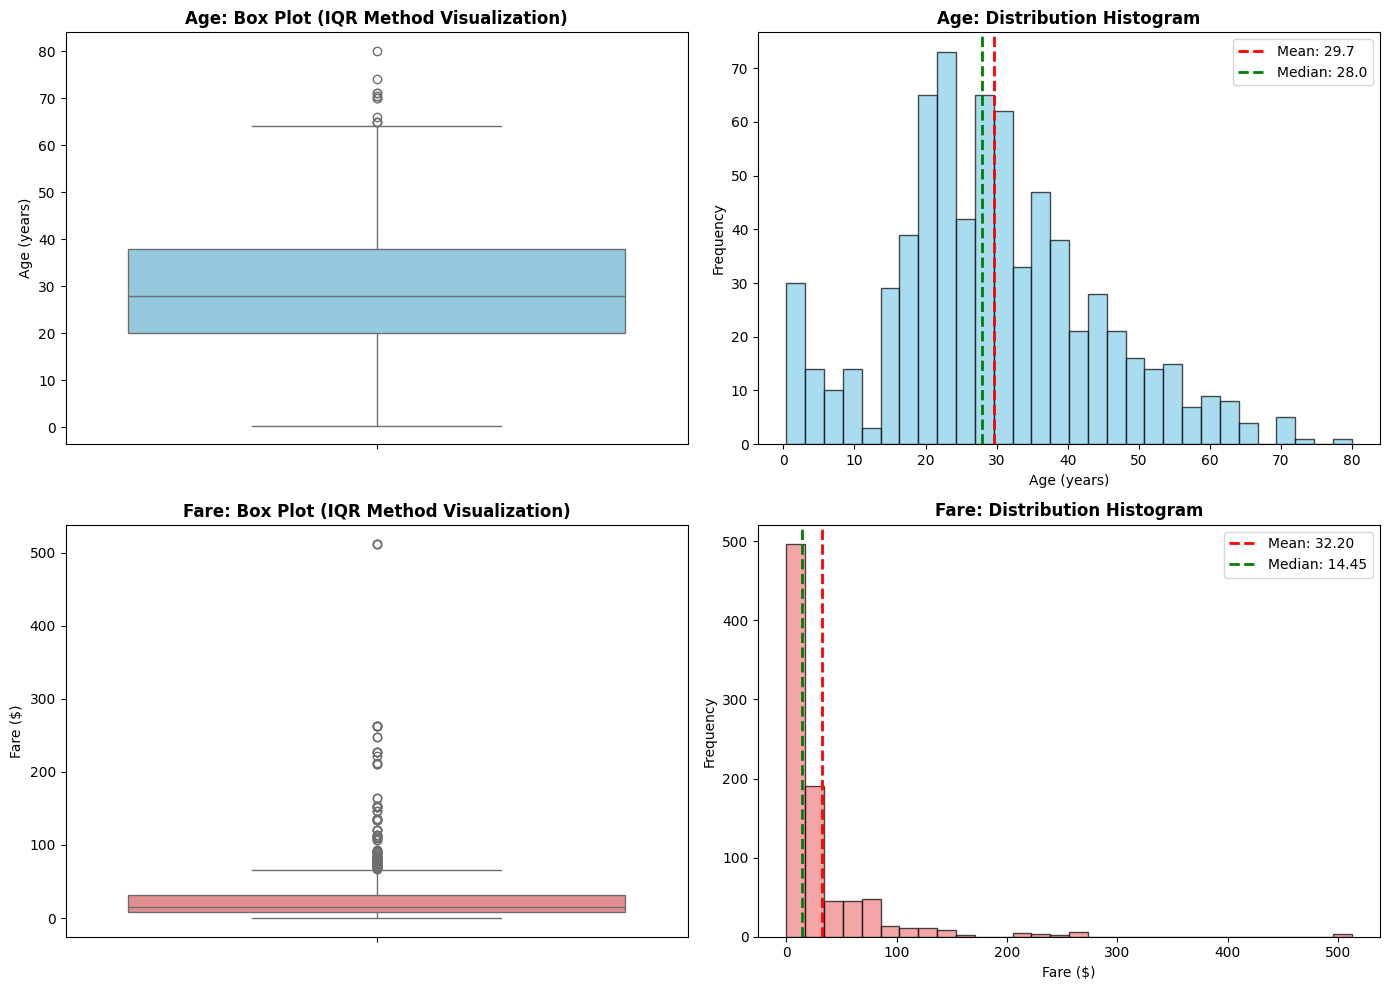


VISUAL ANALYSIS COMPLETE


In [28]:
# ===== VISUAL PRESENTATION & Z-SCORE ANALYSIS =====
# We'll analyze Age and Fare columns

# Step 1: Create box plots and histograms for Age and Fare
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ROW 1: AGE
# Box plot for Age
sns.boxplot(data=train_data, y='Age', ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Age: Box Plot (IQR Method Visualization)', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Age (years)')

# Histogram for Age
axes[0, 1].hist(train_data['Age'].dropna(), bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Age: Distribution Histogram', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Age (years)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].axvline(train_data['Age'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {train_data["Age"].mean():.1f}')
axes[0, 1].axvline(train_data['Age'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {train_data["Age"].median():.1f}')
axes[0, 1].legend()

# ROW 2: FARE
# Box plot for Fare
sns.boxplot(data=train_data, y='Fare', ax=axes[1, 0], color='lightcoral')
axes[1, 0].set_title('Fare: Box Plot (IQR Method Visualization)', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Fare ($)')

# Histogram for Fare
axes[1, 1].hist(train_data['Fare'].dropna(), bins=30, color='lightcoral', edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Fare: Distribution Histogram', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Fare ($)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].axvline(train_data['Fare'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {train_data["Fare"].mean():.2f}')
axes[1, 1].axvline(train_data['Fare'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {train_data["Fare"].median():.2f}')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("VISUAL ANALYSIS COMPLETE")
print("="*60)

*By looking at the histograms, I can make a couple of assumptions before I move to the last part of the Outlier inspection:
- The Age column's majority of records are as I've found out from previous checks that it's around the young to middle-aged adult. No extra-ordinary values are seen on histogram since range is just above 0 to just below 80, and of course like it's been imposed before- ages of value-type float especially around the 0-value area will have to be dealt with on the next chapter which is Data Preprocessing. Overall no extra outlier inspection is required for this column, however z-score analysis will still be used just to triple check.

- The box and histogram plots for the Fare column show that not only the majority but more than that- almost all of the records- fall within the lower-medium end of the column range- thus the upper bound for this column was 65.6344 while Fare prices go up to 512! This shows that most people on board were probably 3rd class ticket holders and wealthy passengers were only a small percentage of the passengers. No further extra-ordinary prices are seen through the plot. This column will also undergo the last z-score analysis to triple check as well. Lastly, there is this small questionable fact, that no fares exist from around the 280 area and up to the 500 area. So does that mean no tickets at all were being sold between that range? Why that may be? Just food for thought. I don't think these are data errors, it just means that there wer eprobably fixed prices for difference classes and also different routes (embarkation from different ports), or there were some sort of group and individual tickets. Eventually, these are pure historical data without immediate affection to the dataset's efficiency.

*Now for the last part of Outlier Inspection I will apply z-score intuition. The way this works is similar to the Z-Score normalisation which is that all the values are being brought down to the -3 -> 3 range, however in this version of it a good rule of thumb is that:
- |Z| > 2 = Moderate outlier (only 5% of normal data should be here)
- |Z| > 3 = Extreme outlier (only 0.3% of normal data should be here)

Overall, it measures how many standard deviations a value is away from the mean.

In [29]:
# Calculate Z-scores to identify statistical outliers
from scipy import stats

def analyze_zscore(data, column, threshold=3):
    """
    Z-score measures how many standard deviations away from the mean a value is.
    Values with |z-score| > 3 are extreme outliers (99.7% of data falls within ±3), 
    0.3% FALLS OUTSIDE

    Values with |z-score| > 2 are moderate outliers (95% of data falls within ±2),
    5% FALLS OUTSIDE
    """
    
    # Remove NaN values for z-score calculation
    col_data = data[column].dropna()
    
    # Calculate z-scores
    z_scores = np.abs(stats.zscore(col_data))
    
    # Find outliers
    outlier_threshold = threshold
    outliers_mask = z_scores > outlier_threshold
    outlier_count = outliers_mask.sum()
    outlier_percentage = (outlier_count / len(col_data)) * 100
    
    print(f"\n{'='*60}")
    print(f"Z-SCORE ANALYSIS FOR: {column.upper()}")
    print(f"{'='*60}")
    print(f"Mean: {col_data.mean():.2f}")
    print(f"Std Dev: {col_data.std():.2f}")
    print(f"\nOutliers with |Z-score| > {threshold}:")
    print(f"  Count: {outlier_count}")
    print(f"  Percentage: {outlier_percentage:.2f}%")
    
    if outlier_count > 0:
        print(f"\nExtreme {column} values (Z-score > {threshold}):")
        outlier_indices = np.where(z_scores > outlier_threshold)[0]
        outlier_values = col_data.iloc[outlier_indices].sort_values(ascending=False)
        print(outlier_values.head(10))
    
    return z_scores, outliers_mask

# Analyze Age with Z-scores
age_zscores, age_outliers_mask = analyze_zscore(train_data, 'Age', threshold=3)

# Analyze Fare with Z-scores
fare_zscores, fare_outliers_mask = analyze_zscore(train_data, 'Fare', threshold=3)

# Also check moderate outliers (|Z-score| > 2)
print("\n\n" + "="*60)
print("MODERATE OUTLIERS (|Z-score| > 2)")
print("="*60)
age_moderate = analyze_zscore(train_data, 'Age', threshold=2)
fare_moderate = analyze_zscore(train_data, 'Fare', threshold=2)


Z-SCORE ANALYSIS FOR: AGE
Mean: 29.70
Std Dev: 14.53

Outliers with |Z-score| > 3:
  Count: 2
  Percentage: 0.28%

Extreme Age values (Z-score > 3):
630    80.0
851    74.0
Name: Age, dtype: float64

Z-SCORE ANALYSIS FOR: FARE
Mean: 32.20
Std Dev: 49.69

Outliers with |Z-score| > 3:
  Count: 20
  Percentage: 2.24%

Extreme Fare values (Z-score > 3):
258    512.3292
679    512.3292
737    512.3292
27     263.0000
341    263.0000
438    263.0000
88     263.0000
311    262.3750
742    262.3750
118    247.5208
Name: Fare, dtype: float64


MODERATE OUTLIERS (|Z-score| > 2)

Z-SCORE ANALYSIS FOR: AGE
Mean: 29.70
Std Dev: 14.53

Outliers with |Z-score| > 2:
  Count: 29
  Percentage: 4.06%

Extreme Age values (Z-score > 2):
630    80.0
851    74.0
493    71.0
96     71.0
116    70.5
745    70.0
672    70.0
33     66.0
54     65.0
280    65.0
Name: Age, dtype: float64

Z-SCORE ANALYSIS FOR: FARE
Mean: 32.20
Std Dev: 49.69

Outliers with |Z-score| > 2:
  Count: 38
  Percentage: 4.26%

Extreme F

*By looking at the results I can at last validate the assumptions and conclusions that I've made for the two columns:
- For the <u>Age</u> column, two records had more than 3 Z-score which mean that they're extreme outliers, the values for those records are 84.0 and 72.0 which are normal age values. Also, 20 records fell under the second category of having more than 2 Z-score which again those values are normal age values. Overall, the percentage of outliers on both z-score values are within the normal range 0-5%, so the Age column passes the third check and no extra-ordinary outliers were detected at least with this value format of float-type.

- For the <u>Fare</u> column, a small percentage of 2.24% are within the range of more than 3 z-score indicating the high value tickets sold for the titanic. Also, for the z-score value of more than 2 the percentage remains again low at 4.26%. These two percentages remain again among the normal z-score range of 0-5% and even though the ones that are more than 3 are quite a few (20 overall) showing the data is right-skewed and not as evenly distributed as the Age one with the lower percentages, this again doesn't show any random noise or extreme values. Of course the mian issue with this column is the values that have up to 4 decimals, however this will be tackled later on. Eventually, the Fare column passes the third check of outlier inspection.

----------------------------------------
----------------------------------------
---------------------------------------
## Data Preprocessing

On this chapter I will be working on fiding the bets way to deal with the issues that were identified across the EDA chapter. This chapter will include the below topics:
- Organise Data Formats/Types
- Data Cleansing (Handle missing/abnormal values)
- Check for Duplicates (Redundancy Check)

----------------------------------------
----------------------------------------
### Organise Data Formats/Types

Let's start by checking again the data types for each column on the dataset.

In [30]:
print(test_data.info())
print(train_data.info())

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Sex          418 non-null    int64  
 3   Age          332 non-null    float64
 4   SibSp        418 non-null    int64  
 5   Parch        418 non-null    int64  
 6   Fare         417 non-null    float64
 7   Embarked     418 non-null    str    
dtypes: float64(2), int64(5), str(1)
memory usage: 26.3 KB
None
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Sex          891 non-null    int64  
 4   Age          714 non-null    float64
 5   SibSp        891 non-null    in

As seen on the results, the <u>Age</u> column has the issue of being of type <u>float</u>. Other than that, the rest of the columns doesn't show any sign of being of certain wrong data formats.

However, in order to tackle this issue I will have to move on to the next part of <i>Data Preprocessing</i>, which is the <u>Data Cleansing</u> where invalid/missing data are replaced. I can't just force the Float64-type data to change to int64-type data.

----------------------------------------
----------------------------------------
### Data Cleansing (Handle missing/abnormal values)



Starting with the <u>Age</u> column, I need to think of how to approach this issue. Should I :
1) Round decimals to nearest integer?
2) Drop those rows?
3) Use an approximate (mean/median) value to replace those weird ones?

Well, the answer may lie between the above. If I were to round the decimals to the nearest integer then that would result in a lot of records having the age of 0 (practically impossible). But then should I drop them? Again, no I shouldn't- because even if the age is off, the rest of the columns may still be predictive and help the model derrive results and patterns from them. At last, using a mean value feels a "neutral" option which is not necessarily bad nor great.

What I will do next is to gather up all the records that have less than 1 age, and then check how many Parch they had and also the Fare value. If those don't align for those of a passenger whose an infant, then I will assume that the age of 0.67 is actuall 67.0 or even 6.7

In [31]:
train_data.loc[train_data['Age'] < 1]


,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
78,79,1,2,1,0.83,0,2,29.0000,S
305,306,1,1,1,0.92,1,2,151.5500,S
469,470,1,3,0,0.75,2,1,19.2583,C
644,645,1,3,0,0.75,2,1,19.2583,C
755,756,1,2,1,0.67,1,1,14.5000,S
803,804,1,3,1,0.42,0,1,8.5167,C
831,832,1,2,1,0.83,1,1,18.7500,S


*By looking at the results I can see that most people with an age of less than 0 had a reasonably low fare. However this low fare is NOT less than the median value (roughly 14$) and also doesn't really justify the fact that an infant would pay this amount for a ticket. On top of that the "black sheep" of these results is this record that has an Age of 0.92 and a Fare of 151.55- this is reasonable when looking at the fare and teh Pclass columns however an "infant" paying this amount sounds ridiculous of course. 

Lastly, when looking at the Parch numbers we can see something interesting. All of the records have more than 0 Parents or children aborad. This then raises the question do these numbers mean that there were infants traveloing with 1-2 parents OR the 0.83 becomes 83 and values mean actually children they were travelling with? Taking into consideration the prices of the tickets, I'm leaning towards the second scenario.

In conclusion, what I will do is that I will <u>change the <1 values and move the decimal point to steps to the right (x100)</u> and the generally across all the column I will apply the <u>rounding to closest integer</u> step. Also, for the missing values I wil be <u>using the median value</u> since the data is right-skewed and I want to avoid bias introduced by the upper tail of the distribution. 

In [32]:
# STEP ONE: GET RID OF AGE VALUES < 1
# mask = train_data['Age'] < 1
# train_data.loc[mask, 'Age'] = train_data.loc[mask, 'Age'] * 100
train_data.loc[train_data['Age'] < 1, 'Age'] *= 100
train_data.loc[train_data['Age'] < 1] # quick check that nothing is returned
test_data.loc[test_data['Age'] < 1, 'Age'] *= 100
test_data.loc[test_data['Age'] < 1] # quick check that nothing is returned

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked


In [33]:
# STEP TWO: REPLACE NAN VALUES WITH MEDIAN
median_age = train_data['Age'].median()
train_data['Age'] = train_data['Age'].fillna(median_age)
test_data['Age'] = test_data['Age'].fillna(median_age)


In [34]:
# STEP THREE: ROUND UP ALL VALUES TO CLOSEST INTEGER
train_data['Age'] = train_data['Age'].round()
train_data.head(5) # quick check changes
test_data['Age'] = test_data['Age'].round()
test_data.head(5) # quick check changes


,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,892,3,1,34.0,0,0,7.8292,Q
1,893,3,0,47.0,1,0,7.0000,S
2,894,2,1,62.0,0,0,9.6875,Q
3,895,3,1,27.0,0,0,8.6625,S
4,896,3,0,22.0,1,1,12.2875,S


In [35]:
# # STEP FOUR: CHANGE FORMAT OF AGE COLUMN TO INTEGER
print(train_data['Age'].isna().sum())
print(test_data['Age'].isna().sum())

train_data['Age'] = train_data['Age'].astype(int)
print(train_data.head(5))
test_data['Age'] = test_data['Age'].astype(int)
print(test_data.head(5))

0
0
   PassengerId  Survived  Pclass  Sex  Age  SibSp  Parch     Fare Embarked
0            1         0       3    1   22      1      0   7.2500        S
1            2         1       1    0   38      1      0  71.2833        C
2            3         1       3    0   26      0      0   7.9250        S
3            4         1       1    0   35      1      0  53.1000        S
4            5         0       3    1   35      0      0   8.0500        S
   PassengerId  Pclass  Sex  Age  SibSp  Parch     Fare Embarked
0          892       3    1   34      0      0   7.8292        Q
1          893       3    0   47      1      0   7.0000        S
2          894       2    1   62      0      0   9.6875        Q
3          895       3    1   27      0      0   8.6625        S
4          896       3    0   22      1      1  12.2875        S


Now the Age column has been preprocessed and it is ready to be used by a model.

Moving onto the next columns, let's have a look on missing entries within other columns:

In [36]:
print(train_data.info())
print(test_data.info())

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Sex          891 non-null    int64  
 4   Age          891 non-null    int64  
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Fare         891 non-null    float64
 8   Embarked     889 non-null    str    
dtypes: float64(1), int64(7), str(1)
memory usage: 62.8 KB
None
<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Sex          418 non-null    int64  
 3   Age          418 non-null    int64  
 4   SibSp        418 non-null    in

*By having a quick look at the above, I can see that the <b>Embarked</b> column is missing <b>two entries</b> on the train dataset and the <b>Fare</b> column is missing <b>one entry</b> on the train dataset. So let's start by dealing with these two:

Since the <u>Embarked</u> column is of type str and has only three character values it can get, using the median or mean is not a good practice and math should not be combined with strings. So, in order to fill out the missing/invalid values I will be using the most frequent value of this text-categorical column- but after checking first that there are no weird values in the column first.

In [37]:
train_data.loc[~train_data['Embarked'].isin(['C', 'Q', 'S'])] # check no other than these three values exist within the dataset
print(train_data['Embarked'].value_counts())
print(train_data['Embarked'].isna().sum()) # verification before filling ONLY ON TRAIN


Embarked
S    644
C    168
Q     77
Name: count, dtype: int64
2


In [38]:
# Use the most frequent text-catgorical value to fill out the invalid/missing data ONLY ON TRAIN
most_common = train_data['Embarked'].mode()[0]
train_data['Embarked'] = train_data['Embarked'].fillna(most_common)

In [39]:
print(train_data['Embarked'].isna().sum()) # last verification

0


*Now moving onto the <u>Fare</u> column, there is only one value missing and just like with the Age column, I will be using the median in order to replace that missing value. Once that is done, I will start working on getting rid of the 4 decimals and I will make the prices more normal.

In [40]:
print(test_data['Fare'].isna().sum()) # quick verification ONLY ON TEST

1


In [41]:
median_age = train_data['Fare'].median()
test_data['Fare'] = test_data['Fare'].fillna(median_age)
print(test_data['Fare'].isna().sum()) # last verification ONLY ON TEST

0


After going through the EDA chapter on the Fare column specifically, I came across this "issue" that Fare prices had 3-4 decimals which of course is not realistic. So from here I have a few options with this:
- I could check how many records have 0, 1, 2, 3, and 4 decimals and if all or most of them have >=2, then I could multiply them with 100 and bring them to more real-life prices. However, if there are a couple of values with less than 2 decimals then using this multiplication would make the range of the column vast and I would have prices from 30$ to 5k$.

- The other side of this issue is that this not really an issue. The values are not depicted correctly when compared to real money however models don't see rational money values, they only see numbers and rarely removing decimal precision values actually helps a model.

In conclusion, since I am not predicting prices and it doesn't make a difference in a good way if the prices are in "human-standards", <b>I will just be leaving this column as it is.</b>

In [42]:
print(train_data.info())
print(test_data.info())

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Sex          891 non-null    int64  
 4   Age          891 non-null    int64  
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Fare         891 non-null    float64
 8   Embarked     891 non-null    str    
dtypes: float64(1), int64(7), str(1)
memory usage: 62.8 KB
None
<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Sex          418 non-null    int64  
 3   Age          418 non-null    int64  
 4   SibSp        418 non-null    in

----------------------------------------

<b>ONE</b> last thing that will need to be taken care of is the <u>Embarked</u> column which is of type <i>str</i>, and since our prodictions will be made through models that use numerical data strictly (the most basic being logistic regression), then this column's values need to be replaced with numerical values.<br><br>
<u>However</u>, if values like Q -> 0, S -> 1, C -> 2 were given then this would all fall apart since the model would think that C > S > Q, which is not the case here and we just want the model to combine columns and identify/learn patterns. <br><br>
A solution to this would be using the <b>One-Hot Encoding</b> technique in order to convert these strings into <u>binary vectors</u>, which are something machine learning models can understand.

In [43]:
train_data = pd.get_dummies(train_data, columns=["Embarked"])
test_data = pd.get_dummies(test_data, columns=["Embarked"])

train_data["Embarked_C"] = train_data["Embarked_C"].astype(int)
train_data["Embarked_Q"] = train_data["Embarked_Q"].astype(int)
train_data["Embarked_S"] = train_data["Embarked_S"].astype(int)

test_data["Embarked_C"] = test_data["Embarked_C"].astype(int)
test_data["Embarked_Q"] = test_data["Embarked_Q"].astype(int)
test_data["Embarked_S"] = test_data["Embarked_S"].astype(int)

# test_data = test_data.reindex(columns=train_data.columns, fill_value=0)
print(train_data.info())
print(test_data.info())

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Sex          891 non-null    int64  
 4   Age          891 non-null    int64  
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Fare         891 non-null    float64
 8   Embarked_C   891 non-null    int64  
 9   Embarked_Q   891 non-null    int64  
 10  Embarked_S   891 non-null    int64  
dtypes: float64(1), int64(10)
memory usage: 76.7 KB
None
<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Sex          418 non-null    int64  

After running this last check for any invalid data or missing data, I am assured that I can move on to the last stage of this Data Preprocessing chapter which is the <i>Check Redundancy/Duplicates</i>

----------------------------------------
----------------------------------------
### Check for Duplicates (Redundancy Check)

*The mental model that I will be following for this part is the following:
- I will start by checking each column for duplicates/redundancy.
- However, columns of categorical data type shouldn't be checked since it is normal for them to have duplicates. So I will only keep the ones that matter the most- <u>Age</u> and <u>Fare</u>.
- IF any duplicates are found (especially on the Fare column which has values with up to 4 decimals), then without moving into any conclusions yet, I will start adding other coluns to the "equation" to check overall redundancy between records.
- Lastly, if I do find any redundant/duplicated data, I still won't remove them because since the <b>Name</b> and <b>PassengerId</b> columns have been dropped from the dataset for this walkthrough, then I don't have any other way to check that the records refer to actual different people. Maybe the <u>Sex</u> column could help if it's about couples but still not very straightforward.

In [44]:
# First checking the Age column if it has any duplicates
print(train_data.duplicated(subset=['Age']).sum())
print(test_data.duplicated(subset=['Age']).sum())

817
353


This by itself doesn't mean much since a lot of ages can be duplicated therefore let's add to the equation more columns:

In [45]:
print(train_data.duplicated(subset=['Age', 'Pclass', 'Sex', 'SibSp', 'Parch', 'Embarked_C', 'Embarked_Q', 'Embarked_S', 'Survived']).sum())
print(train_data.duplicated(subset=['Age', 'Pclass', 'Sex', 'SibSp', 'Parch', 'Embarked_C', 'Embarked_Q', 'Embarked_S', 'Survived']).sum())


320
320


Again, this insight only means that there are 320 (and 131 respectively) duplicates of a previous row under the subset that has the column specified. So 320 means that 320 records are duplicated of a previous record (but doesn't mean that all of them are duplicates of the same record). So, without any further info about the Name, PassengerId, etc- I cannot make any final conclusions just yet!

That's why I will now check the Fare column and then add to the above subset/"equation" the Fare column as well which will be a very good "first layer redundancy check".

In [46]:
# Secondly checking the Fare column if it has any duplicates
print(train_data.duplicated(subset=['Fare']).sum())
print(test_data.duplicated(subset=['Fare']).sum())

643
249


Now this is quite concerning on one hand because having unique values that have up to 4 decimals means precision. So how can so many entries have at least one duplicate with such precision? The only logical answer would be that most of the ticket Fares are fixed values. Passengers travelling without family members at the same class, will surely have paid the same Fare as others with the same characteristics (and so on for other types of passengers).

So in order to now get a last rough idea of duplicates within the dataset, I will add the Fare column on the overall subset:

In [47]:
print(train_data.duplicated(subset=['Age', 'Pclass', 'Sex', 'SibSp', 'Parch', 'Embarked_C', 'Embarked_Q', 'Embarked_S', 'Survived', 'Fare']).sum())
print(train_data.duplicated(subset=['Age', 'Pclass', 'Sex', 'SibSp', 'Parch', 'Embarked_C', 'Embarked_Q', 'Embarked_S', 'Survived', 'Fare']).sum())


117
117


In conclusion, I can see that there is a good amount of duplicated records within the two datasets however just how I implied in the beginning of this chapter, since no Name, PassengerId, and other columns exist within the dataset to verify authenticity of the records and the data. Therefore, no columns will be removed and the dataset passed the Redundancy Check in this first simple walkthrough!

----------------------------------------
----------------------------------------
---------------------------------------
## Model Creation, Testing, and Evaluation 

<b>First Attempt and Model will be created using the processed datasets. Once that chapter is done, I will try the same type of model process on more the "pure"/raw original dataset verison which includes values like 0.83 on the <u>Age</u> column, and so on. The reason behind this is so that I can compare which model is the best and if reasoning with data and trying to "clean" them in such way actually ends up helping at all.</b>

### First Prediction Attempt

In [48]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [49]:
train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Sex          891 non-null    int64  
 4   Age          891 non-null    int64  
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Fare         891 non-null    float64
 8   Embarked_C   891 non-null    int64  
 9   Embarked_Q   891 non-null    int64  
 10  Embarked_S   891 non-null    int64  
dtypes: float64(1), int64(10)
memory usage: 76.7 KB


<b>First separate features and labels into:<br>
y -> what am i predicting?<br>
x -> evertything else needed to train the model</b>

In [50]:
# Step 1: split X and y
X_train = train_data.drop("Survived", axis=1) # all except the Survived column
y_train = train_data["Survived"]

X_test = test_data
# y_test = ? NO SURVIVED COLUMN ON TEST DATASET SINCE ITS A KAGGLE COMPETITION AND THERE IS NO WAY TO 
# ACTUALLY EVALUATE THE MODEL RATHER THAN UPLOADING IT AND SEEING HOW MUCH IT SCORES ON THE COMP

# Step 2: create model
no_test_data_MODEL = LogisticRegression()

# Step 3: train
no_test_data_MODEL.fit(X_train, y_train)

# Step 4: predict
predictions = no_test_data_MODEL.predict(X_test)

print(predictions)

[0 1 0 0 1 0 1 0 1 0 0 0 1 0 1 1 0 0 1 1 0 0 1 0 1 0 1 0 0 0 0 0 1 1 0 0 1
 1 0 0 0 0 0 1 1 0 0 0 1 1 0 0 1 1 0 0 0 0 0 1 0 0 0 1 1 1 1 0 0 1 1 0 1 0
 1 1 0 1 0 1 0 1 0 0 0 0 1 1 1 0 1 0 1 0 0 0 1 0 1 0 1 0 0 0 1 0 0 0 0 0 0
 1 1 1 1 0 0 1 1 1 1 0 1 0 0 1 0 1 0 0 0 0 1 0 0 0 0 0 1 0 1 1 1 0 0 0 0 0
 0 0 1 0 0 1 0 0 1 1 0 1 1 0 1 0 0 1 0 0 1 1 0 0 0 0 0 1 1 0 1 1 0 0 1 0 1
 0 1 0 0 0 0 0 0 0 0 0 1 1 0 1 1 0 1 1 0 0 1 0 1 0 0 0 0 1 0 0 1 1 1 0 1 0
 1 0 1 1 0 1 0 0 0 1 0 0 0 0 1 0 1 1 1 1 1 0 0 0 1 0 1 1 1 0 1 0 0 0 0 0 1
 0 0 0 1 1 0 0 0 0 1 0 1 0 1 1 0 1 0 0 0 0 1 0 1 1 1 0 0 0 0 0 0 1 0 0 0 0
 1 0 0 0 0 0 0 0 1 1 1 0 0 1 0 0 0 1 1 1 1 0 0 0 0 0 0 0 1 0 1 1 0 0 1 0 0
 1 0 0 0 0 0 0 0 0 0 1 0 1 0 1 0 1 1 0 0 0 1 0 1 0 0 1 0 1 1 0 1 0 0 1 1 0
 0 1 0 0 1 1 1 0 0 0 0 0 1 1 0 1 0 0 0 0 1 1 0 0 0 1 0 1 0 0 1 0 1 0 0 0 0
 1 1 1 1 1 1 0 1 0 0 0]


/Users/grigoriostsakalis/Desktop/Titanic - ML Project/titanic_venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


**A better way to approach this is by splitting the train dataset into two other datasets one for training and one for testing**

In [51]:
X = train_data.drop(["Survived", "PassengerId"], axis=1)
y = train_data["Survived"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) 
# a random state of 89 returned better prediction accuracy however it doesn't really affect the model's
# performance since it just changes which data goes into and other parameters/features will be needed to make the model's prediction accuracy better

test_data_MODEL = LogisticRegression(max_iter=100)

# Step 3: train
test_data_MODEL.fit(X_train, y_train)

# passenger_ids = test_data["PassengerId"]

# Step 4: predict
# X_test = test_data.drop("PassengerId", axis=1)
predictions = test_data_MODEL.predict(X_test)

# Step 5: evaluate
accuracy = accuracy_score(y_test, predictions)

print(accuracy)

0.7932960893854749


/Users/grigoriostsakalis/Desktop/Titanic - ML Project/titanic_venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [52]:
# test_data.head()
train_data.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,1,22,1,0,7.2500,0,0,1
1,2,1,1,0,38,1,0,71.2833,1,0,0
2,3,1,3,0,26,0,0,7.9250,0,0,1
3,4,1,1,0,35,1,0,53.1000,0,0,1
4,5,0,3,1,35,0,0,8.0500,0,0,1


----------------------------------------
### Second Attempt

In this attempt I will be removing the passenger_id column from the train datasets so that it won't make the training process "noisy". Also, I will apply some feature engineering where a new column <u>Family Size</u> will be created that comes from the sum of the <b>SibSp</b> and <b>Parch</b> columns, to see if that makes the model predict better.

----------------------------------------
### Third Attempt

This is the second to last attempt in which I will take a step back and add again the names on the train dataset in order to then <u>extract the titles from the names (Mrs/Mr)</u>. Once this step is done and the prediction accuracy is not satisfying my requirements, I will then move to the final stage of the model creation which is <b>Cross Validation</b>.

<u>Next step</u> is to use <b>Cross-Validation</b>, tweak the <b>C regularisation strenght</b> parameter, and the <b>max_ter</b> parameter on the logistic regression object

**Once a decent model has been made, the line of code below should be used to get the final prediction based on the test dataset too, and then the notebook can be submitted on Kaggle**

<u>predictions = model.predict(test_data)</u>